In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('01-2026.csv')

In [3]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,100191621513,2026-01-01 10:09,Inbound,00:00:00,NaN,NaN
1,100154993020,2026-01-01 10:12,Outbound,00:03:34,NaN,Tyler Smith
2,100194977164,2026-01-01 11:15,Inbound,00:00:00,NaN,NaN
3,100193579152,2026-01-01 12:01,Inbound,00:00:00,NaN,NaN
4,100194230636,2026-01-01 14:21,Inbound,00:00:00,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17300 entries, 0 to 17299
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             17300 non-null  int64  
 1   Activity date         17300 non-null  object 
 2   Call direction        17106 non-null  object 
 3   Call duration         17188 non-null  object 
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  15983 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 811.1+ KB


In [5]:
df1 = df.drop(columns = ['hs_call_outcome', 'Record ID'])

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17300 entries, 0 to 17299
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Activity date         17300 non-null  object
 1   Call direction        17106 non-null  object
 2   Call duration         17188 non-null  object
 3   Activity assigned to  15983 non-null  object
dtypes: object(4)
memory usage: 540.8+ KB


In [7]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format = "%Y-%m-%d %H:%M",
    errors = "coerce"
)

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17300 entries, 0 to 17299
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         17300 non-null  datetime64[ns]
 1   Call direction        17106 non-null  object        
 2   Call duration         17188 non-null  object        
 3   Activity assigned to  15983 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 540.8+ KB


# Call Count per day

In [9]:
df2 = df1.copy()

In [10]:
df2['date'] = df2['Activity date'].dt.date

In [11]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2026-01-01 10:09:00,Inbound,00:00:00,NaN,2026-01-01
1,2026-01-01 10:12:00,Outbound,00:03:34,Tyler Smith,2026-01-01
2,2026-01-01 11:15:00,Inbound,00:00:00,NaN,2026-01-01
3,2026-01-01 12:01:00,Inbound,00:00:00,NaN,2026-01-01
4,2026-01-01 14:21:00,Inbound,00:00:00,NaN,2026-01-01


In [12]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns = {'Activity date': 'date'})
)

In [13]:
daily_calls.head()

,date,call_count
0,2026-01-01,10
1,2026-01-02,280
2,2026-01-03,5
3,2026-01-04,2
4,2026-01-05,817


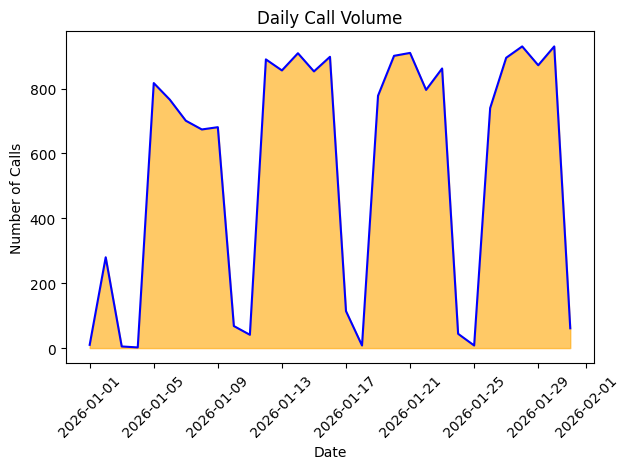

In [14]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color = 'orange', alpha=0.6)

plt.title('Daily Call Volume')
plt.xlabel('Date')
plt.ylabel('Number of Calls')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [15]:
df1['day'] = df1['Activity date'].dt.day_name()

In [16]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2026-01-01 10:09:00,Inbound,00:00:00,NaN,Thursday
1,2026-01-01 10:12:00,Outbound,00:03:34,Tyler Smith,Thursday
2,2026-01-01 11:15:00,Inbound,00:00:00,NaN,Thursday
3,2026-01-01 12:01:00,Inbound,00:00:00,NaN,Thursday
4,2026-01-01 14:21:00,Inbound,00:00:00,NaN,Thursday


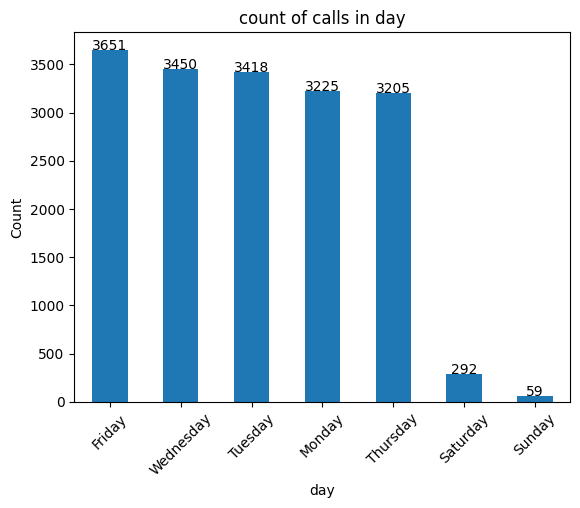

In [17]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

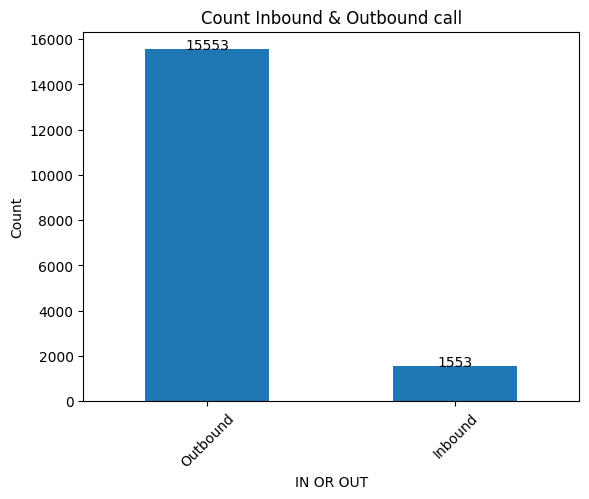

In [18]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel("IN OR OUT")
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [19]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

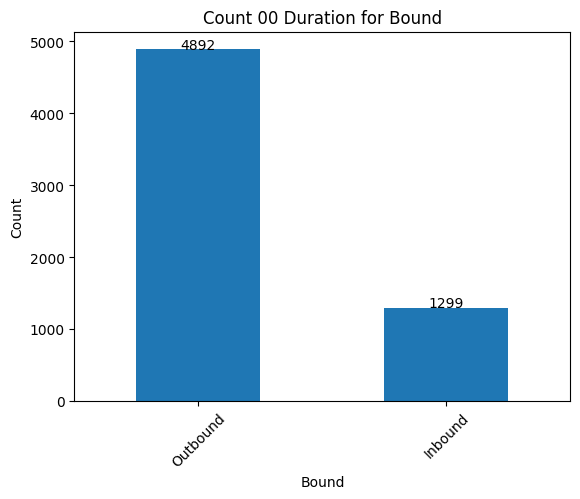

In [20]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [21]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
7603,2026-01-16 10:53:00,Outbound,NaN,Tommy Canfield,Friday


In [22]:
df4 = df1.copy()

In [23]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [24]:
(df4['Call duration'] == 0).sum()

6191

In [25]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17300 entries, 0 to 17299
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         17300 non-null  datetime64[ns]
 1   Call direction        17106 non-null  object        
 2   Call duration         17188 non-null  float64       
 3   Activity assigned to  15983 non-null  object        
 4   day                   17300 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 675.9+ KB


In [26]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [27]:
df4 = df4.dropna(subset = ['Call direction'])

In [28]:
(df4['Call duration'] == 0).sum()

6192

In [29]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17106 entries, 0 to 17299
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         17106 non-null  datetime64[ns]
 1   Call direction        17106 non-null  object        
 2   Call duration         17106 non-null  float64       
 3   Activity assigned to  15800 non-null  object        
 4   day                   17106 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 801.8+ KB


# Working Call Assigner

In [30]:
df1['Activity assigned to'].nunique()

37

In [31]:
df1['Activity assigned to'].unique()

array([nan, 'Tyler Smith', 'Kunal Rajani', 'Oliver Martin', 'Zach Drissi',
       'Garrett Evans', 'Isaiah Trousil', 'Jerry Guadiana',
       'Robin Stoehr', 'Sam Steindorf', 'Tommy Canfield',
       'Georgi Stanchev', 'Chrystel Manabat', 'Jannica Nikka Antipuna',
       'Jinky Rance', 'Marvin Laguna', 'David Valdez', 'Jerome Joyce',
       'Cameron Byrd', 'Andrew Stewart', 'Salvador Pardo',
       'Cameron Dudley', 'Keith Antonio', 'Paol Guzman', 'Tyler Jury',
       'David Banister', 'Matt Jones', 'Juan Calo', 'Alejandra Hanks',
       'Abhi C', 'Brittany Digiulio', 'Shawn Richardson',
       'Adonis Baybayan', 'Nick Rothacher', 'Bill Goodwin',
       'Andrew Huvaere', 'Terry Kim', 'Davon Miller'], dtype=object)

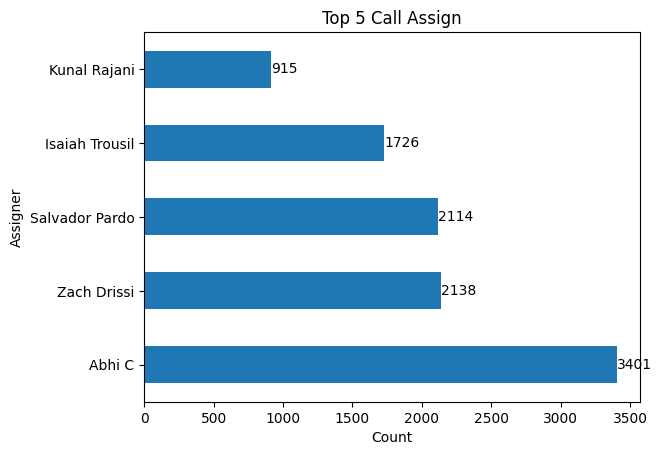

In [32]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [33]:
df4['Call duration'].max()

104.43333333333334

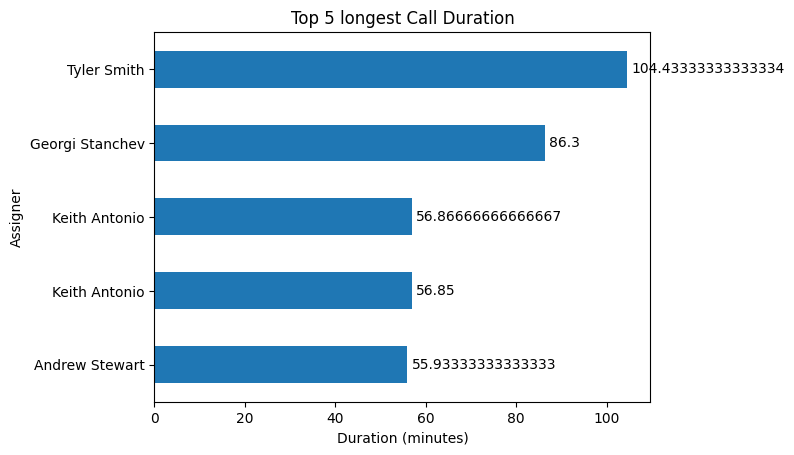

In [34]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [35]:
df3 = df1.copy()

In [36]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [37]:
df3['day'].unique()

array(['Thursday', 'Friday', 'Monday', 'Tuesday', 'Wednesday'],
      dtype=object)

In [38]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

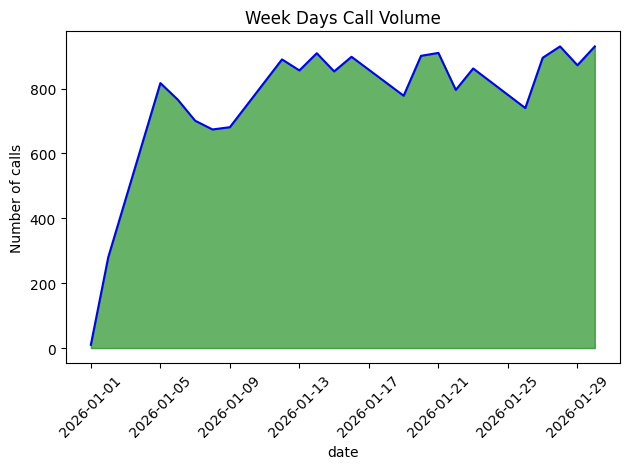

In [39]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [40]:
df5=df4.copy()

In [41]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [42]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
290,2026-01-03 12:01:00,Inbound,0.000000,NaN,Saturday
291,2026-01-03 12:15:00,Inbound,0.000000,NaN,Saturday
292,2026-01-03 13:04:00,Inbound,27.216667,Sam Steindorf,Saturday
293,2026-01-03 15:08:00,Inbound,0.000000,NaN,Saturday
294,2026-01-03 21:03:00,Inbound,0.000000,NaN,Saturday


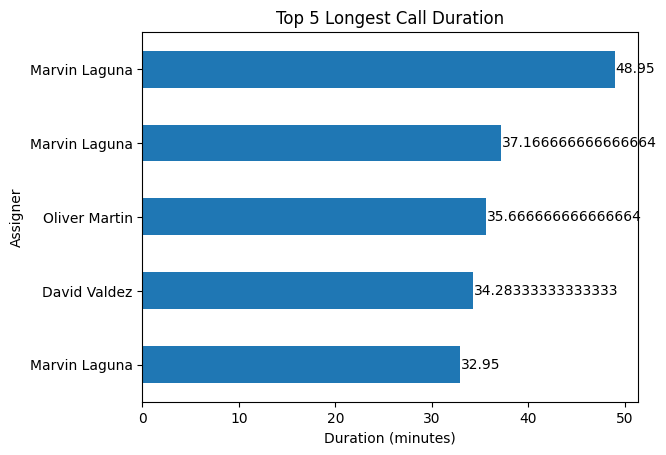

In [43]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

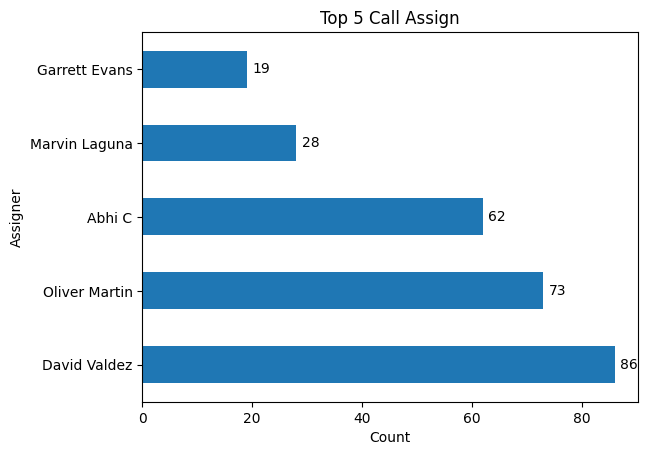

In [44]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [45]:
df4["Call duration"].mean()

1.8436922717175261

In [46]:
df4["Call duration"].median()

0.06666666666666667

# Without Call Assigner Calls

In [47]:
df6 = df3.copy()

In [48]:
df6['month'] = df6['Activity date'].dt.month_name()

In [49]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

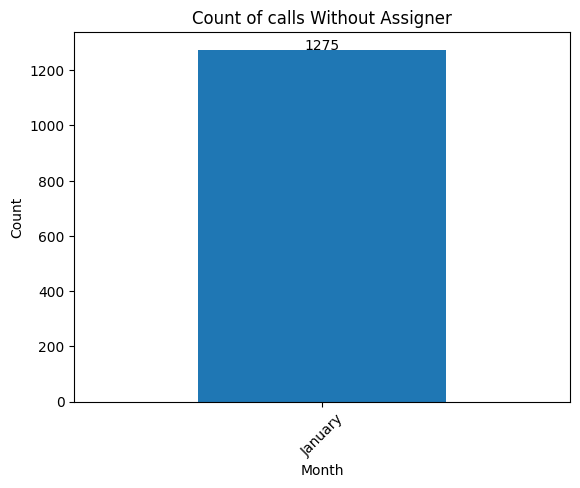

In [50]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call Date

In [51]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [52]:
top5 = daily_calls.sort_values(ascending=False).head(5)

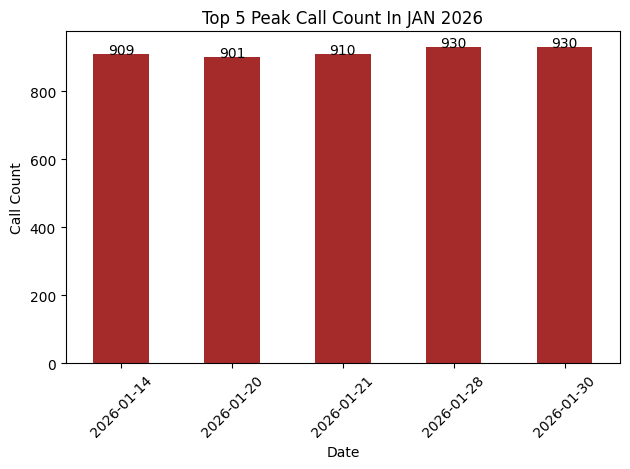

In [53]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In JAN 2026")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()